# Statistics II Practice – Project Cycle 1
Exploratory Data Analysis Workflow (Diabetes.csv)

## Overview

This notebook is the required template for **Project Cycle 1**.

You must complete the **TO DO** parts and write interpretations.
- Use **matplotlib** for plotting in required sections.
- Keep the notebook **runnable from top to bottom**.
- Work as a **group** and make sure every member understands the notebook.

Project question (Cycle 1):
**Which characteristics appear related to diabetes (Outcome) in this dataset?**


## 0. Setup

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# USE YOUR GROUP NUMBER AS THE SEED
SEED = 10  # TO DO: set your group seed (keep it fixed for reproducibility)
np.random.seed(SEED)


## 1. Load and Inspect the Dataset

Required file: `Diabetes.csv`

TO DO:
1) Load the CSV into a DataFrame named `df`  
2) Display the first 5 rows  
3) Report: number of rows, number of columns  
4) Check data types  


In [19]:
# TO DO: load dataset (hint: pd.read_csv)
import pandas as pd
df = pd.read_csv("Diabetes.csv")


# Preview first 5 rows
df.head()
#df:DataFrame（從 Diabetes.csv 讀進來的資料表）
#.head()用來查看資料的前幾筆資料(預設是5筆)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
# TO DO: show dataset shape (rows, columns)
df.shape #shape 是 Pandas 的屬性，用來顯示資料的維度(rows, columns)
print("Rows:", df.shape[0]) #rows的數量
print("Columns:", df.shape[1]) #columns的數量

Rows: 768
Columns: 9


In [21]:
# TO DO: inspect data types and non-null counts
df.info()
#df.info()是用來了解資料結構
# 有幾筆資料RangeIndex
# 有幾個變數Column names
# 每個變數的型態Data Types(int64整數、float64小數)
# 有沒有缺失值(這個欄位有768個有效資料；如果少於768 → 代表有 missing values)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Interpretation (3–5 lines):
- How many observations and variables?
- What is the outcome variable?
- What types of variables do you see (continuous vs discrete/binary)?


#Continuous	測量值（BMI、血壓、血糖）
#Discrete 次數（Pregnancies）
#Binary	只有0或1（Outcome）
The dataset contains 768 observations and 9 variables.
The Outcome variable indicates whether a patient has diabetes (1) or not (0).
Variables such as Glucose, BMI, and Age are continuous variables.
Pregnancies is a discrete variable and Outcome is a binary variable.

## 2. Data Quality Checks

TO DO:
1) Summary statistics (`describe`)  
2) Missing value check  
3) Identify suspicious values (e.g., zeros where impossible/unlikely)  


In [22]:
# TO DO: summary statistics (hint: df.describe()) #摘要統計
summary = df.describe() #看整個資料的基本狀況（統計摘要）
summary

#它會幫你算出每個數值欄位的：
#有幾筆資料（count）
#平均數（mean）
#標準差（std）→ 看資料分散程度
#最小值（min）
#最大值（max）
#四分位數（25%、50%、75%）→ 看資料分布

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [23]:
# TO DO: missing values count (hint: df.isna().sum())
missing_counts = df.isna().sum() #檢查每一個欄位有幾個缺失值（Missing Values）
missing_counts

#df.isna()會把整個資料表變成
#✔ 有缺失值 → True
#✔ 沒缺失值 → False

#.sum()會把
#True = 1
#False = 0


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [24]:
# TO DO (optional): count how many zeros appear in selected variables
# # Why? In some datasets, 0 may represent 'missing' for measurements.
#檢查這幾個醫學變數裡面，有幾筆資料是 0 (血壓、BMI、血糖不可能是0)，0 其實代表「缺失值」
vars_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = (df[vars_to_check] == 0).sum()
# hint: (df[vars]==0).sum()
zero_counts

#df[vars_to_check] == 0 → 每一格都問：是不是 0？
#(df[vars_to_check] == 0).sum() → 把 True 數量加起來
#df[vars_to_check]:只選出這幾個欄位來檢查
#== 0:把資料變成 True / False
#是 0 → True
#不是 0 → False

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Interpretation (5–8 lines):
- Are there missing values?
- Which variables have suspicious values?
- What might those suspicious values mean for analysis (e.g., missing coded as 0)?


There are no obvious missing values based on the standard missing value check.
but several variables such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI contain a noticeable number of zero values,In medical data, these measurements are unlikely to be zero.
Therefore, these zero values may actually represent missing data that were coded as 0.

## 3. Required Visualizations (Matplotlib Default)

You must produce the following plots using **matplotlib**:

A) Histogram of Glucose  
B) Histogram of BMI  
C) Boxplot of Glucose by Outcome  
D) Scatter: Age vs BMI (use color/marker by Outcome)

After each plot, write a short interpretation (2–4 lines).


### 3A. Histogram of Glucose

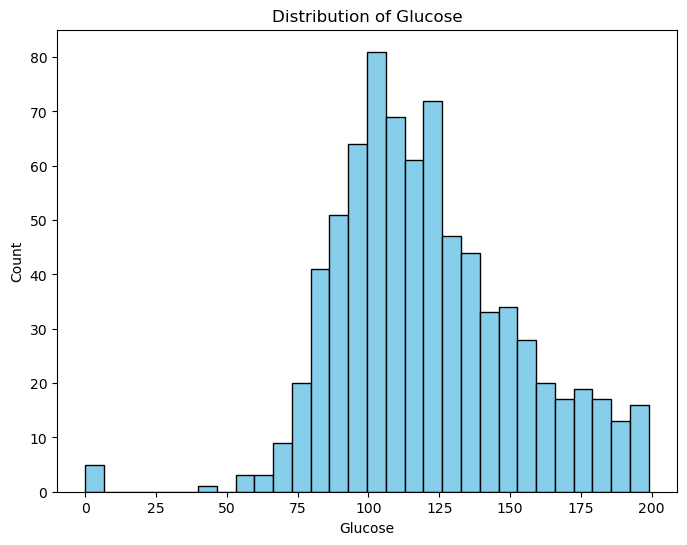

In [25]:
# TO DO: histogram of Glucose (hint: plt.hist)
# Use 30 bins.
import matplotlib.pyplot as plt #載入繪圖工具 matplotlib，並把它簡寫成 plt
plt.figure(figsize=(8,6)) #建立一張新的圖表(寬 8、高 6)
plt.hist(df["Glucose"], bins=30, color="skyblue", edgecolor="black")

#plt.hist(...)：畫 直方圖
#df["Glucose"]：拿資料表裡的 Glucose 這一欄
#bins=30：把資料分成 30 個區間
#color="skyblue"：柱子的顏色是淺藍色
#edgecolor="black"：每個柱子的邊框是黑色

plt.title("Distribution of Glucose") #圖表標題
plt.xlabel("Glucose") #X 軸名稱
plt.ylabel("Count") #Y 軸名稱(每個區間裡有幾筆資料)
plt.show() #把圖顯示出來


Interpretation: Describe shape, center, spread, and any unusual features/outliers.

The distribution of glucose appears slightly right-skewed.
The center of the data seems to be around the middle glucose range.
The spread is fairly wide, showing variation in glucose levels among individuals.
There are some unusual low values (including zeros) and a few high values that may be potential outliers.

### 3B. Histogram of BMI

<Figure size 640x480 with 0 Axes>

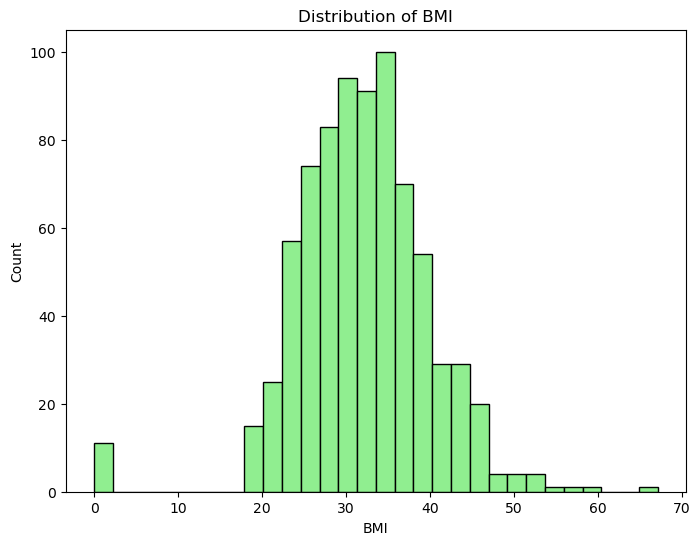

In [26]:
plt.figure()

# TO DO: histogram of BMI (hint: plt.hist)
# Use 30 bins.
plt.figure(figsize=(8,6))
plt.hist(df["BMI"], bins=30, color="lightgreen", edgecolor="black")

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()


Interpretation: Describe shape, center, spread, and any unusual features/outliers.

The distribution is right-skewed and centered around 30–35, with a spread extending from 0 to 60. A significant unusual feature is the cluster of outliers at 0, which likely indicates missing or incomplete data records.

### 3C. Boxplot: Glucose by Outcome

C:\Users\CNC_413\AppData\Local\Temp\ipykernel_18572\3432435639.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g0, g1], labels=["Outcome=0", "Outcome=1"], patch_artist=True,


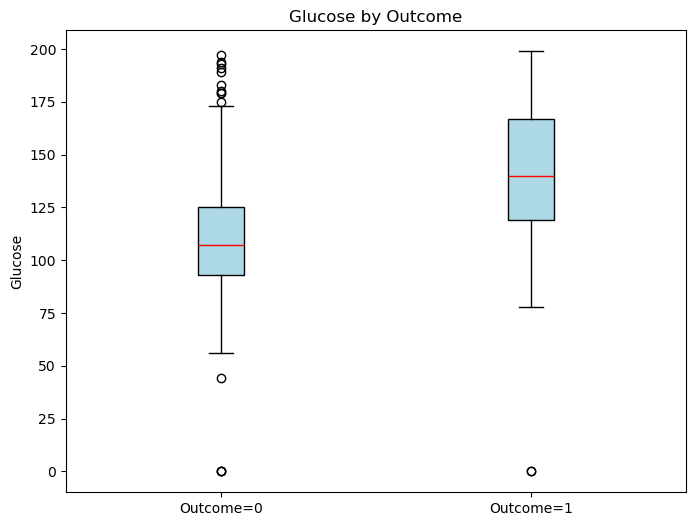

In [27]:
# TO DO: create two groups of Glucose values by Outcome
g0 = df[df["Outcome"] == 0]["Glucose"]
g1 = df[df["Outcome"] == 1]["Glucose"]
#把資料分成兩群人(有糖尿病(1)、沒有糖尿病(0))
#df就是整份糖尿病資料

#df["Outcome"]:拿出outcome那一欄
#df["Outcome"] == 0 :是不是等於 0？(結果會是true、false)
#df[ 這個 True/False ]:True → 保留這列、False → 刪掉這列


#只留下 Outcome = 0 (沒有糖尿病)的列，再只拿血糖這一欄(沒有糖尿病的人血糖數值) = g0
#只留下 Outcome = 1 (有糖尿病)的列，再只拿血糖這一欄(有糖尿病的人血糖數值) = g1


plt.figure(figsize=(8,6))
#開一張新的圖

# TO DO: boxplot comparing the two groups (hint: plt.boxplot)
# labels should be ["Outcome=0", "Outcome=1"]

plt.boxplot([g0, g1], labels=["Outcome=0", "Outcome=1"], patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="black"),
            medianprops=dict(color="red"))
#同時畫兩個箱型圖 → 比較
#labels=["Outcome=0", "Outcome=1"] :設定X軸的名稱
#patch_artist=True(箱子可以填顏色)
#箱子裡面顏色 → 淺藍色、箱子邊框 → 黑色
#中位數那條線畫成紅色

plt.title("Glucose by Outcome")
plt.ylabel("Glucose")
plt.show()
#糖尿病與血糖的關係

Interpretation: Compare medians and variability. Do the groups appear separated?

The median glucose level: Outcome = 1 > Outcome = 0
The variability: Outcome = 1 > Outcome = 0 
Although the two groups overlap, the boxplots show some separation, suggesting higher glucose levels are associated with diabetes.

### 3D. Scatter: Age vs BMI (by Outcome)

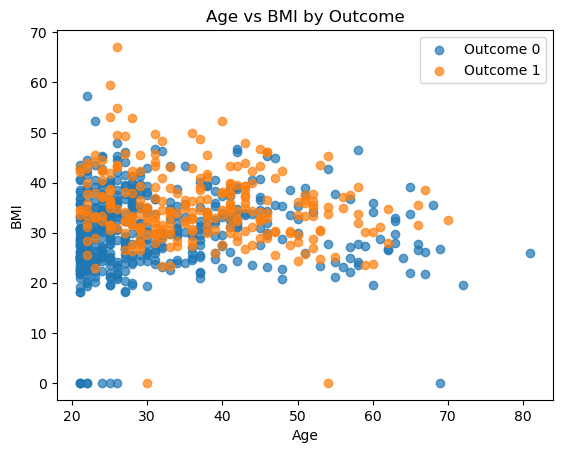

In [28]:
# TO DO: split dataset by Outcome
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("diabetes.csv")

#pandas → 用來處理資料表、matplotlib → 用來畫圖
#把diabetes.csv 讀進來變成一張表叫 df


df0 = df[df["Outcome"] == 0]
df1 = df[df["Outcome"] == 1]

#df0 → 沒有糖尿病的人、df1 → 有糖尿病的人

plt.figure()
#開一張新的圖

# TO DO: scatter plots for the two groups (hint: plt.scatter)
# Use alpha=0.7 and include labels.
plt.scatter(df0["Age"], df0["BMI"], alpha=0.7, label="Outcome 0")
#第一組散佈圖(X 軸 → 年齡、Y 軸 → BMI)
#alpha=0.7 → 點有點透明
#label → 圖例名稱

plt.scatter(df1["Age"], df1["BMI"], alpha=0.7, label="Outcome 1")

plt.title("Age vs BMI by Outcome")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.legend() #顯示圖例
plt.show()

#觀察年齡與 BMI 是否有關係
#同時看看糖尿病與否的人分布是否不同

#年齡與 BMI 的關係不明顯
#糖尿病組（橘色）比較多集中在較高 BMI
#有一些異常點(BMI 接近 0 的點)


Interpretation: Do you see clustering or separation between groups?

clustering : with diabetes at higher BMI levels.
But the two groups still largely overlap across ,there is no clear separation between the groups based only on Age and BMI.

## 4. Group Comparison Summary (Descriptive)

TO DO:
1) Compute group means for Glucose, BMI, Age by Outcome  
2) Compute mean differences (Outcome=1 minus Outcome=0)  


In [29]:
# TO DO: group means table (hint: groupby + mean)
summary_means = df.groupby("Outcome")[["Glucose", "BMI", "Age"]].mean()
summary_means

#groupby("Outcome")把資料分成兩組(0、1)
#並比較血糖、BMI、年齡
#.mean():對每一組人計算平均值

#比較糖尿病與非糖尿病族群的平均差異(糖尿病的人平均血糖是否比較高？平均 BMI 是否比較大？年齡是否比較高？)


,Glucose,BMI,Age
Outcome,,,
0,109.980000,30.304200,31.190000
1,141.257463,35.142537,37.067164


In [30]:
# TO DO: compute mean differences (Outcome=1 minus Outcome=0)
# hint: summary_means.loc[1] - summary_means.loc[0]
mean_diff = summary_means.loc[1] - summary_means.loc[0]
mean_diff

#前一題已經算出平均值summary_means
#.loc[1] : 拿出 Outcome = 1 那一整列
#.loc[0] : 拿出 Outcome = 0 那一整列
#summary_means.loc[1] - summary_means.loc[0] : 糖尿病組平均 − 非糖尿病組平均
#最後得到Mean Difference(正數代表糖尿病組比較高)

Glucose    31.277463
BMI         4.838337
Age         5.877164
dtype: float64

Interpretation (5–8 lines):
- Which variables show the biggest differences between Outcome groups?
- Which 1–2 variables look most promising as “associated with Outcome” (based on descriptive evidence)?
- Be cautious: do not claim causality.


Glucose shows the largest difference between the Outcome groups,much higher average levels  with diabetes.
Glucose appears to be the most strongly associated variable with diabetes,BMI and Age also show noticeable differences, but the gaps are smaller compared to Glucose.
However, these results are based on descriptive comparisons only and do not imply causality.

## 5. Sampling Simulation (Concept Preparation)

Goal: understand sampling variability of the sample mean.

TO DO:
1) Sample n = 30 observations (with replacement)  
2) Compute the sample mean of Glucose  
3) Repeat B = 1000 times  
4) Plot the distribution of sample means (matplotlib)  
5) Report the mean and standard deviation of the sampling distribution  


In [31]:
#模擬抽樣平均數會怎麼變動
#同一份資料中，假如只抽30個人，算出來的平均血糖會不會每次都一樣?

#從資料裡 隨機抽 30 筆 Glucose 資料（放回抽樣）
#把剛剛抽到的 30 筆 Glucose 算出它們的平均數
#抽 30 筆 → 算平均」這件事，重複做 1000 次 (會有1000個sample mean)
#把這 1000 個平均數畫成直方圖(平均數的分布)
#再算這1000個平均數的平均數和標準差

# TO DO: set simulation parameters
B = 1000 #要重複抽取1000次
n = 30 #每一次要抽30筆資料
means = [] #建立一個空的list清單(把每一次算出來的sample mean放進去，共1000個)



In [32]:
#載入numpy(把list轉成array)

import numpy as np
B = 1000          # bootstrap 次數(做1000次)
n = len(df)       # sample size (資料表有幾筆資料)

means = [] #存抽樣後平均血糖的地方

#重複抽樣(抽資料、算平均、存起來)
for b in range(B):
    # TO DO: draw a bootstrap sample of size n (with replacement)
    sample =  df.sample(n=n, replace=True)  # hint: df.sample
    #從整張資料表隨機抽n筆
    #n=n =抽樣數量 = 我剛剛設定的樣本大小
    #replace=True(抽到一筆後會放回去)

    # TO DO: compute mean of Glucose in this sample
    m =sample["Glucose"].mean() #計算這次抽樣的平均Glucose
    
    means.append(m) #把這次算出的平均數加入清單
means = np.array(means) #把list變成數值陣列


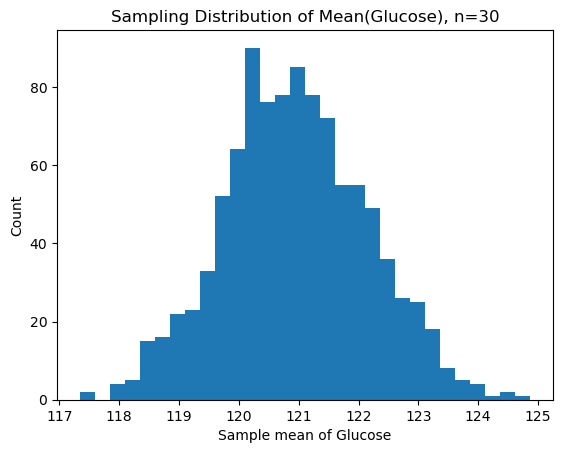

In [33]:
#畫「抽樣平均數的分布圖」(Sampling distribution)

import matplotlib.pyplot as plt
plt.figure() #開一張新的圖

# TO DO: histogram of simulated sample means (hint: plt.hist)
plt.hist(means, bins=30) #把剛剛模擬得到的 1000 個平均數畫成直方圖

#means : 每次抽樣算出的平均Glucose
#bins : 把平均數分成30個區間


plt.title("Sampling Distribution of Mean(Glucose), n=30") #樣本大小等於30時，平均血糖的抽樣分布
plt.xlabel("Sample mean of Glucose") #每一次抽樣算出的平均血糖
plt.ylabel("Count") #有幾次抽樣得到這個平均範圍
plt.show()

#如果一直抽樣，平均血糖會集中在哪裡？會不會差很多？(Sampling variability)


In [34]:
#「抽樣平均數分布」的中心與分散程度

# TO DO: report center and spread of the sampling distribution
# hint: means.mean() and means.std(ddof=1)
center = means.mean() #這 1000 個 sample mean 的平均值(中心)(長期抽樣後的穩定位置)
spread = means.std(ddof=1) #抽樣平均數的標準差(ddof樣本標準差公式)
center, spread



(120.94150911458334, 1.204372043759695)

Interpretation (5–8 lines):
- What does the sampling distribution represent?
- Is it narrower than the raw Glucose distribution? Why?
- How does this connect to uncertainty of an estimate?


The sampling distribution represents how the sample mean of Glucose varies across repeated random samples.It shows the possible values that the sample mean can take due to sampling variability.
Compared with the raw Glucose distribution, the sampling distribution is much narrower,because averaging reduces variability and extreme values tend to cancel out.
A narrower sampling distribution indicates that the sample mean is a more stable estimate of the population mean.

## Week B Consultation Checklist (Must Be Completed Before Consultation)

Before Week B, your group must have a **runnable draft** that includes:

1) Sections 1–5 completed (code runs without errors)  
2) All required plots (3A–3D) displayed correctly  
3) Group summary table (Section 4) + a short conclusion paragraph  
4) Sampling simulation completed (Section 5) + interpretation  
5) A proposed extension idea for Week C (next section)

No runnable draft → no Week B consultation mark.


## 6. Week C Extension

Choose **one** extension direction. The extension should add insight beyond the required analysis.

Examples (choose one):
- Correlation analysis (heatmap or top correlations with Outcome)
- Compare medians instead of means (robustness)
- Create age groups and compare outcomes across age bins
- Create BMI categories and compare outcome rates
- Another visualization (density, pairwise, etc.)

Write your plan first, then implement below.


Create age groups and compare outcomes across age bins

### 6A. Extension Plan (5–8 lines)
TO DO: Write your plan here.

In this extension, patients will first be divided into age groups (young, middle-aged, and older) based on predefined cut-off values.
Within each age group, patients will be further categorized into low and high BMI groups.
This stratified approach allows us to examine how diabetes prevalence differs across combined age and BMI categories.
For each subgroup, the mean value of the Outcome variable will be calculated to represent the probability of diabetes.
The results will be summarized in a table and visualized using a grouped bar chart.
This analysis aims to explore whether the effect of BMI on diabetes risk varies across different age groups.
Such patterns may provide additional insight beyond simple comparisons of overall group means.

### 6B. Extension Implementation (code + outputs)

C:\Users\CNC_413\AppData\Local\Temp\ipykernel_18572\1549522540.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df.groupby(["AgeGroup", "BMIGroup"])["Outcome"].agg(["count", "mean"]).reset_index()


Summary Table:
  AgeGroup  BMIGroup  Count  DiabetesRate
0    Young  High BMI    279      0.369176
1    Young   Low BMI    209      0.110048
2   Middle  High BMI    146      0.582192
3   Middle   Low BMI     45      0.311111
4      Old  High BMI     47      0.659574
5      Old   Low BMI     42      0.285714

Pivot Table for Plot:
BMIGroup  High BMI   Low BMI
AgeGroup                    
Young     0.369176  0.110048
Middle    0.582192  0.311111
Old       0.659574  0.285714


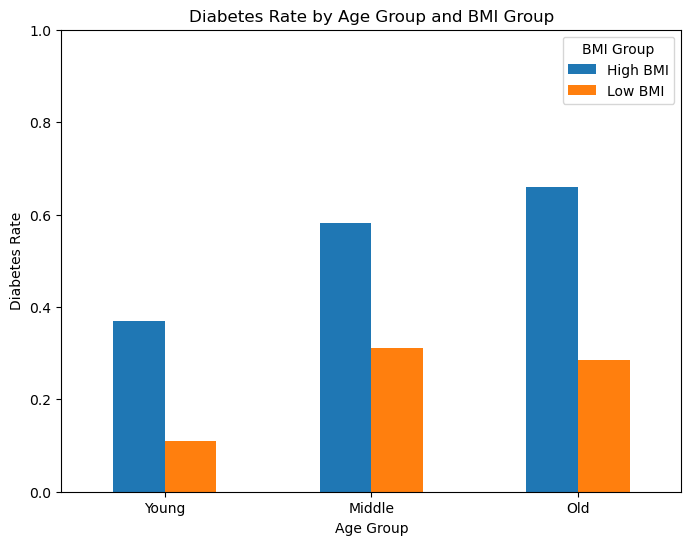

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("diabetes.csv")

# -----------------------------
# Step 1: Create Age groups
# -----------------------------
# Young: Age < 35
# Middle: 35 <= Age <= 50
# Old: Age > 50

age_bins = [0, 35, 50, np.inf]
age_labels = ["Young", "Middle", "Old"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# -----------------------------
# Step 2: Create BMI groups
# -----------------------------
# Low BMI: BMI < 30
# High BMI: BMI >= 30

df["BMIGroup"] = np.where(df["BMI"] < 30, "Low BMI", "High BMI")

# -----------------------------
# Step 3: Compute summary table
# -----------------------------
summary_table = df.groupby(["AgeGroup", "BMIGroup"])["Outcome"].agg(["count", "mean"]).reset_index()

# Rename columns for clarity
summary_table.columns = ["AgeGroup", "BMIGroup", "Count", "DiabetesRate"]

print("Summary Table:")
print(summary_table)

# -----------------------------
# Step 4: Pivot table for plotting
# -----------------------------
plot_data = summary_table.pivot(index="AgeGroup", columns="BMIGroup", values="DiabetesRate")

print("\nPivot Table for Plot:")
print(plot_data)

# -----------------------------
# Step 5: Plot grouped bar chart
# -----------------------------
plot_data.plot(kind="bar", figsize=(8,6))

plt.title("Diabetes Rate by Age Group and BMI Group")
plt.xlabel("Age Group")
plt.ylabel("Diabetes Rate")
plt.ylim(0, 1)   # because Outcome mean is a proportion
plt.legend(title="BMI Group")
plt.xticks(rotation=0)
plt.show()

### 6C. Extension Interpretation (5–8 lines)
TO DO: Interpret what your extension shows and how it supports/changes your conclusions.

The results show that diabetes prevalence increases with age across both BMI groups.
Within each age category, individuals with high BMI consistently have higher diabetes rates than those with low BMI.
The difference between high and low BMI appears larger among older individuals, suggesting a possible interaction effect.
This indicates that the impact of BMI on diabetes risk may become stronger as age increases.
Overall, both age and BMI seem to play important roles in diabetes risk.

## 7. Week C Exhibition Reflection (After Rotations)

After you visit other groups during Week C, write at least **three** items:

1) One interesting analysis/visualization idea you saw  
2) One interpretation insight that was better than yours (what and why)  
3) One improvement you would apply to your own workflow next time  


Reflection notes:

1)In some of the teams who has the table of Heatmap-table some get the analysis,but the other did not.

2)In speakers some did not tall the all detall in their project.

3)Most of the teams did not notice some reason have to cleaning,before the analysis.

